[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter1_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 1: Stylised Facts and Returns

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza — Bucharest University of Economic Studies.*

- **Part A**: numerical check of the eleven pen-and-paper exercises (warm-ups A1, A3, A5, A6; derivations A2, A4, A7–A11).
- **Part B**: B1–B8 verify the stylised facts; B9–B15 test them with inference robust to heavy tails and clustering.
- **Part C**: an open question for the team project, with a reference analysis.
- **[Solved]** problems are fully worked out (code and output); **[Proposed]** problems have an empty cell for you: their solutions are discussed in the seminar.
- Every proposed problem follows a solved model: A2 after A1; A4 after A5; A8, A9, A10 after A6; A11 after A7; B2, B6, B7 after B1; B4, B5 after B3; B8 after A5; B10, B12, B13 after B9; B14 after B3 and B11; B15 after B9 and B11.

> The solutions are discussed in the seminar.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import warnings
warnings.filterwarnings('ignore')
import sys
if 'google.colab' in sys.modules:
    !pip -q install arch
import statsmodels.api as sm

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
Teal     = '#17A2B8'

ASSETS = ['sp500', 'bettr', 'btc', 'eurron', 'gold']
COLORS = {'sp500': MainBlue, 'bettr': IDAred, 'btc': Amber, 'eurron': Forest, 'gold': Purple}
PERIODS = {'sp500': 252, 'bettr': 252, 'btc': 365, 'eurron': 252, 'gold': 252}


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import tempfile
TABLE_DIR = tempfile.gettempdir()   # tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

SOURCES = {
    'sp500':  ('GSPC.INDX',    'close', '1990-01-01'),
    'bettr':  ('BETTR.INDX',   'close', '2014-09-01'),
    'btc':    ('BTC-USD.CC',   'close', '2014-09-17'),
    'eurron': ('REF:EUR',      'close', '2005-07-01'),   # de la introducerea leului nou (RON), 1 iulie 2005
    'gold':   ('XAUUSD.FOREX', 'close', '1990-01-01'),
}

LABELS = {'sp500': 'S&P 500', 'bettr': 'BET-TR (Romania)', 'btc': 'Bitcoin',
          'eurron': 'EUR/RON', 'gold': 'Gold'}

# cotatii OTC (aur): sesiunile partiale de sambata/duminica rup randamentul vineri -> luni,
# deci pastram doar zilele lucratoare (aceeasi conventie ca in Capitolul 0)
WEEKDAYS_ONLY = {'gold'}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    df = pd.read_csv(src, parse_dates=['date']).set_index('date').sort_index()
    df.index.name = 'Date'
    return df


def read_reference_rate(currency='EUR', start='2005-07-01', end='2026-09-18'):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    import re
    import urllib.request
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    df = pd.DataFrame(rows, columns=['Date', 'Close']).drop_duplicates('Date').set_index('Date')
    df.index = pd.to_datetime(df.index)
    _CACHE[key] = df.sort_index().loc[start:end]
    return _CACHE[key]


def load_data(name='sp500'):
    """OHLCV zilnic cu coloane Open/High/Low/Close/Volume (Close = pretul folosit)."""
    symbol, col, start = SOURCES[name]
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start)
    d = read_market(symbol).loc[start:]
    if name in WEEKDAYS_ONLY:
        d = d[d.index.dayofweek < 5]
    out = pd.DataFrame({'Open': d['open'], 'High': d['high'], 'Low': d['low'],
                        'Close': d[col], 'Volume': d['volume']})
    return out[out['Close'] > 0].dropna(subset=['Close'])


def load_close(name):
    """Pretul de inchidere, folosit in toate graficele."""
    return load_data(name)['Close'].dropna()


closes = {a: load_close(a) for a in ASSETS}
rets = {a: np.log(c).diff().dropna() for a, c in closes.items()}
# gold (weekdays only) is annualised with its actual number of observations per year
PERIODS['gold'] = len(rets['gold']) / ((closes['gold'].index[-1] - closes['gold'].index[0]).days / 365.25)
spx_ohlc = load_data('sp500')
for a in ASSETS:
    print(f'{LABELS[a]:18s}', rets[a].index[0].date(), '->', rets[a].index[-1].date(), len(rets[a]), 'obs')

In [ ]:
SEED = 42
HILL_FRACS_TAILS = np.round(np.arange(0.01, 0.1001, 0.0025), 4)
BLUE_CHIPS = ['TLV.RO', 'SNP.RO', 'BRD.RO', 'TGN.RO', 'FP.RO', 'SNG.RO', 'H2O.RO', 'SNN.RO', 'EL.RO', 'DIGI.RO', 'TEL.RO']


def hill_estimator(x, k):
    """alpha_hat(k) = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^{-1}, X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x)[np.asarray(x) > 0])[::-1]
    return 1.0 / np.mean(np.log(x[:k] / x[k]))


def leverage_corr(r, K=20):
    ks = np.arange(-K, K + 1)
    a = r.abs()
    return ks, np.array([r.corr(a.shift(-k)) for k in ks])     # corr(r_t, |r_{t+k}|)


def rho_robust(r):
    e = (r - r.mean()).values
    s2 = np.sum(e ** 2)
    rho = np.sum(e[1:] * e[:-1]) / s2
    se = np.sqrt(np.sum(e[1:] ** 2 * e[:-1] ** 2)) / s2
    return rho, se


def _kurt_path(x, ends):
    """Excesul de kurtosis pe ferestre extinse [0, e) calculat din sume cumulate (vectorizat pe coloane)."""
    c1, c2, c3, c4 = (np.cumsum(x ** p, axis=0) for p in (1, 2, 3, 4))
    n = ends[:, None].astype(float)
    m1, m2, m3, m4 = (c[ends - 1] / n for c in (c1, c2, c3, c4))
    var = m2 - m1 ** 2
    mu4 = m4 - 4 * m1 * m3 + 6 * m1 ** 2 * m2 - 3 * m1 ** 4
    return mu4 / var ** 2 - 3

## Part A — pen-and-paper exercises (numerical check)

### A1. Returns and annualisation, a warm-up [Solved]

In [5]:
# A1 aggregation over time and across assets
P = np.array([100, 110, 99, 104.5])
R = P[1:] / P[:-1] - 1; r = np.log(P[1:] / P[:-1])
print('R =', R.round(4), ' r =', r.round(4))
print('3-day simple:', round(P[-1] / P[0] - 1, 4), ' sum R:', round(R.sum(), 4), ' 3-day log:', round(np.log(P[-1] / P[0]), 4), ' sum r:', round(r.sum(), 4))
Rp = 0.6 * 0.05 + 0.4 * (-0.02)
print('Rp =', Rp, ' weighted log =', round(0.6 * np.log(1.05) + 0.4 * np.log(0.98), 5),
      ' true log =', round(np.log(1 + Rp), 5))
print('mu_ann =', 252 * 0.0004, ' sigma_ann =', round(np.sqrt(252) * 0.012, 4), ' BTC =', round(np.sqrt(365) * 0.035, 4))

R = [ 0.1    -0.1     0.0556]  r = [ 0.0953 -0.1054  0.0541]
3-day simple: 0.045  sum R: 0.0556  3-day log: 0.044  sum r: 0.044
Rp = 0.022  weighted log = 0.02119  true log = 0.02176
mu_ann = 0.1008  sigma_ann = 0.1905  BTC = 0.6687


### A2. The square-root-of-time rule under autocorrelation [Proposed]

In [ ]:
# Your code here


### A3. Jarque-Bera and Ljung-Box [Solved]

In [7]:
# A3 Jarque-Bera and Ljung-Box
T, Sk, K = 2500, -0.5, 8
print('JB =', round(T / 6 * (Sk**2 + (K - 3)**2 / 4), 1), ' critical =', round(stats.chi2.ppf(0.95, 2), 2))
T, rho = 1000, [0.10, -0.05, 0.03]
print('Q(3) =', round(T * (T + 2) * sum(rk**2 / (T - k) for k, rk in enumerate(rho, 1)), 2),
      ' critical =', round(stats.chi2.ppf(0.95, 3), 2))

JB = 2708.3  critical = 5.99
Q(3) = 13.44  critical = 7.81


### A4. How large should a drawdown be? [Proposed]

In [ ]:
# Your code here


### A5. Parkinson volatility and its efficiency [Solved]

In [9]:
# A5 Parkinson
hl = np.array([1.020, 1.015, 1.030, 1.010, 1.025])
var_p = np.mean(np.log(hl) ** 2) / (4 * np.log(2))
print('daily vol =', round(100 * np.sqrt(var_p), 3), '%  annualised =', round(100 * np.sqrt(252 * var_p), 2), '%')
from scipy.special import zeta
v = 9 * zeta(3) / (16 * np.log(2) ** 2) - 1
print(f'Var(Parkinson) = {v:.3f} sigma^4;  efficiency vs r^2 = {2 / v:.2f}')
# simulation check: Brownian paths with 2,000 steps per day
rng = np.random.default_rng(7); W = np.cumsum(rng.standard_normal((20000, 2000)) / np.sqrt(2000), axis=1)
rg = W.max(1) - W.min(1); print('E[(h-l)^2] =', round(np.mean(rg ** 2), 3), ' 4 ln 2 =', round(4 * np.log(2), 3))

daily vol = 1.259 %  annualised = 19.98 %
Var(Parkinson) = 0.407 sigma^4;  efficiency vs r^2 = 4.91


E[(h-l)^2] = 2.674  4 ln 2 = 2.773


### A6. Kurtosis of a volatility mixture [Solved]

In [10]:
# A6 kurtosis of a volatility mixture
p, s1, s2 = 0.8, 1.0, 2.0
K = 3 * (p * s1**4 + (1 - p) * s2**4) / (p * s1**2 + (1 - p) * s2**2) ** 2
rng = np.random.default_rng(1); sig = np.where(rng.random(1_000_000) < p, s1, s2)
print('K =', round(K, 4), ' simulated K =', round(stats.kurtosis(sig * rng.standard_normal(sig.size), fisher=False), 3))

K = 4.6875  simulated K = 4.682


### A7. The Hill estimator, step by step (hypothetical sample) [Solved]

In [11]:
# A7 The Hill estimator, step by step (hypothetical sample)
X = np.array([12.0, 9.5, 8.2, 7.4, 6.9, 6.1, 5.8, 5.5, 5.2, 5.0, 4.8])
k = 10
logs = np.log(X[:k] / X[k]); alpha = 1 / logs.mean(); se = alpha / np.sqrt(k)
print('logs =', logs.round(3), ' sum =', round(logs.sum(), 3))
print(f'alpha = {alpha:.2f}  SE = {se:.2f}  95% = [{alpha - 1.96 * se:.2f}, {alpha + 1.96 * se:.2f}]')
# the same on the 11 largest BET-TR days
x = np.sort(rets['bettr'].abs().values)[::-1][:11] * 100
print('BET-TR:', x.round(3), ' alpha_10 =', round(1 / np.mean(np.log(x[:10] / x[10])), 2))

logs = [0.916 0.683 0.536 0.433 0.363 0.24  0.189 0.136 0.08  0.041]  sum = 3.616
alpha = 2.77  SE = 0.87  95% = [1.05, 4.48]
BET-TR: [11.857 10.075  7.827  6.707  6.662  6.512  5.972  5.928  5.49   5.285
  5.202]  alpha_10 = 3.38


### A8. Markov-switching mixture: autocorrelation of r^2 [Proposed]

In [ ]:
# Your code here


### A9. Kurtosis of a Gaussian GARCH(1,1) [Proposed]

In [ ]:
# Your code here


### A10. Why the autocorrelation band widens under clustering [Proposed]

In [ ]:
# Your code here


### A11. The Hill estimator as a maximum likelihood estimator [Proposed]

In [ ]:
# Your code here


## Part B — verify (B1–B8)

### B1. Descriptive statistics [Solved]

- Daily log returns for BET-TR, Bitcoin and EUR/RON: N, volatility, skewness, excess kurtosis, minimum, Jarque–Bera.
- Interpretation: recompute the BET-TR kurtosis without its largest day.

In [16]:
# Solution
rows = {}
for a in ['bettr', 'btc', 'eurron']:
    r = rets[a]
    rows[LABELS[a]] = {'N': len(r), 'ann vol %': 100 * r.std() * np.sqrt(PERIODS[a]), 'skew': stats.skew(r),
                       'exkurt': stats.kurtosis(r), 'min %': 100 * r.min(), 'JB': stats.jarque_bera(r).statistic}
print(pd.DataFrame(rows).round(2))
r = rets['bettr']
print('without the largest day:', round(stats.kurtosis(r.drop(r.abs().idxmax())), 2),
      ' without the 5 largest:', round(stats.kurtosis(r.drop(r.abs().nlargest(5).index)), 2))

           BET-TR (Romania)   Bitcoin   EUR/RON
N                   2992.00   4384.00   5352.00
ann vol %             15.52     66.58      4.44
skew                  -1.40     -0.70      0.73
exkurt                17.79     11.96     15.14
min %                -11.86    -46.47     -2.54
JB                 40432.54  26482.02  51575.43
without the largest day: 11.81  without the 5 largest: 5.95


In [17]:
# Robust (quantile-based) skewness and kurtosis, block-bootstrap CIs
def moving_block_indices(T, block, rng):
    """Indicii unui esantion bootstrap pe blocuri mobile (moving-block) de lungime `block`."""
    nb = int(np.ceil(T / block))
    st = rng.integers(0, T - block, nb)
    return (st[:, None] + np.arange(block)[None, :]).ravel()[:T]


def robust_moments(n_boot=1000, block=20, seed=42):
    """Asimetrie si aplatizare pe cuantile (Kim & White 2004): Hinkley (5%-95%) si Crow-Siddiqui
    (2.5%, 97.5% fata de quartile, minus 2.91, valoarea distributiei Normale); IC bootstrap pe blocuri."""
    def qstats(v):
        q = np.quantile(v, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975])
        return ((q[5] + q[1] - 2 * q[3]) / (q[5] - q[1]), (q[6] - q[0]) / (q[4] - q[2]) - 2.91)
    rng = np.random.default_rng(seed)
    rows = []
    for a in ASSETS:
        v = rets[a].values
        sk, ku = qstats(v)
        b = np.array([qstats(v[moving_block_indices(len(v), block, rng)]) for _ in range(n_boot)])
        rows.append({'asset': LABELS[a], 'skew_moment': stats.skew(v), 'skew_hinkley': sk,
                     'skew_lo': np.quantile(b[:, 0], 0.025), 'skew_hi': np.quantile(b[:, 0], 0.975),
                     'exkurt_moment': stats.kurtosis(v), 'kurt_cs': ku,
                     'kurt_lo': np.quantile(b[:, 1], 0.025), 'kurt_hi': np.quantile(b[:, 1], 0.975)})
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_robust_moments.csv'), float_format='%.4g')
    return t


robust_moments().round(3).loc[[LABELS[a] for a in ('bettr', 'btc', 'eurron')]].T

asset,BET-TR (Romania),Bitcoin,EUR/RON
skew_moment,-1.400,-0.705,0.725
skew_hinkley,-0.036,-0.018,0.041
skew_lo,-0.085,-0.069,-0.023
skew_hi,0.024,0.034,0.093
exkurt_moment,17.790,11.958,15.139
kurt_cs,1.057,2.246,4.868
kurt_lo,0.721,1.910,3.757
kurt_hi,1.459,2.656,6.107


### B2. Heavy tails and 1% VaR on BET-TR (in-sample, not a backtest) [Proposed]

- Days beyond 3σ; Student-t fitted by maximum likelihood; 1% VaR (Normal distribution, Student-t, empirical) and breaches on the same sample.

In [ ]:
# Your code here


### B3. Uncorrelated but not independent (Bitcoin) [Solved]

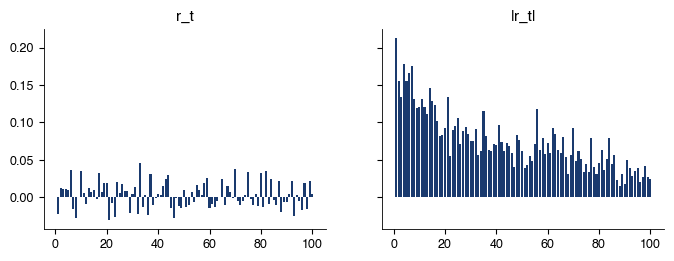

acf1 r = -0.022  acf1 |r| = 0.213
    lb_stat  lb_pvalue
10   20.178      0.028
    lb_stat  lb_pvalue
10  212.745        0.0
ARCH-LM(5) = 114.7


In [19]:
# Solution
r = rets['btc']
fig, ax = plt.subplots(1, 2, figsize=(8, 2.6), sharey=True)
for axi, s_, t in [(ax[0], r, 'r_t'), (ax[1], r.abs(), '|r_t|')]:
    axi.bar(range(1, 101), acf(s_, nlags=100, fft=True)[1:], color=MainBlue); axi.set_title(t)
plt.show()
print('acf1 r =', round(r.autocorr(1), 3), ' acf1 |r| =', round(r.abs().autocorr(1), 3))
print(acorr_ljungbox(r, lags=[10]).round(3)); print(acorr_ljungbox(r**2, lags=[10]).round(3))
print('ARCH-LM(5) =', round(het_arch(r - r.mean(), nlags=5)[0], 1))

### B4. Aggregational Gaussianity (Bitcoin), with approximate standard errors [Proposed]

In [ ]:
# Your code here


### B5. Leverage effect: Romania (BET-TR) vs crypto (Bitcoin) [Proposed]

In [ ]:
# Your code here


### B6. EUR/RON across regimes [Proposed]

In [ ]:
# Your code here


### B7. BET-TR vs S&P 500 on the same period [Proposed]

- Join the **prices** on common dates, then take returns; same-day and lagged correlation.

In [ ]:
# Your code here


### B8. Range-based estimators on the S&P 500 (2008–2026) [Proposed]

- See Lecture 1 on stale index opens: why Yang–Zhang stays below close-to-close.

In [ ]:
# Your code here


## Part B — test (B9–B15)

### B9. Heteroskedasticity-robust Ljung–Box [Solved]

- $\hat\tau_k = \sum x_t^2 x_{t-k}^2/(\sum x_t^2)^2$; $\tilde Q(10) = \sum \hat\rho_k^2/\hat\tau_k$ (Lobato, Nankervis & Savin, 2001).

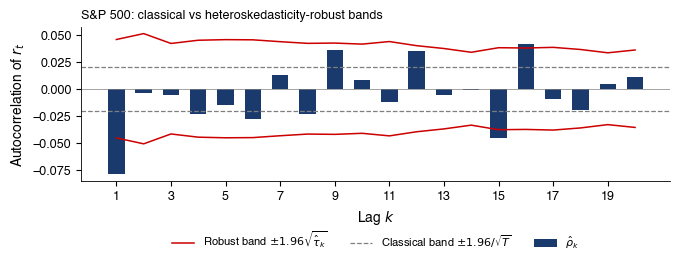

,T,Q10,Q10_p,Qt10,Qt10_p,sig_classic,sig_robust,robust_lags,rho1
asset,,,,,,,,,
S&P 500,9245,91.553,0.0,18.976,0.041,8,3,"[1, 15, 16]",-0.079
BET-TR (Romania),2992,69.976,0.0,16.923,0.076,5,2,"[2, 10]",0.061
EUR/RON,5352,221.658,0.0,37.366,0.000,6,2,"[1, 3]",0.170


In [25]:
# Solution
def robust_lb_table(assets=('sp500', 'bettr', 'eurron'), m_q=10, m_band=20):
    rows = []
    for a in assets:
        x = (rets[a] - rets[a].mean()).values
        T, s2 = len(x), np.sum(x ** 2)
        ks = np.arange(1, m_band + 1)
        rho = np.array([np.sum(x[k:] * x[:-k]) / s2 for k in ks])
        tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
        q = acorr_ljungbox(rets[a], lags=[m_q], return_df=True)
        qt = float(np.sum(rho[:m_q] ** 2 / tau[:m_q]))
        rows.append({'asset': LABELS[a], 'T': T, 'Q10': float(q['lb_stat'].iloc[0]), 'Q10_p': float(q['lb_pvalue'].iloc[0]),
                     'Qt10': qt, 'Qt10_p': float(stats.chi2.sf(qt, m_q)),
                     'sig_classic': int(np.sum(np.abs(rho) > 1.96 / np.sqrt(T))),
                     'sig_robust': int(np.sum(np.abs(rho) > 1.96 * np.sqrt(tau))),
                     'robust_lags': [int(k) for k in ks[np.abs(rho) > 1.96 * np.sqrt(tau)]], 'rho1': rho[0]})
    return pd.DataFrame(rows).set_index('asset')


def fig_robust_acf(asset='sp500', m=20):
    x = (rets[asset] - rets[asset].mean()).values
    T, s2 = len(x), np.sum(x ** 2)
    ks = np.arange(1, m + 1)
    rho = np.array([np.sum(x[k:] * x[:-k]) / s2 for k in ks])
    tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
    fig, ax = plt.subplots(figsize=(6.8, 2.9))
    ax.bar(ks, rho, color=MainBlue, width=0.6, label='$\\hat\\rho_k$')
    ax.plot(ks, 1.96 * np.sqrt(tau), color=IDAred, lw=1.1, label='Robust band $\\pm1.96\\sqrt{\\hat\\tau_k}$')
    ax.plot(ks, -1.96 * np.sqrt(tau), color=IDAred, lw=1.1)
    ax.axhline(1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.9, label='Classical band $\\pm1.96/\\sqrt{T}$')
    ax.axhline(-1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.9)
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(ks[::2] if m > 10 else ks)
    ax.set_xlabel('Lag $k$')
    ax.set_ylabel('Autocorrelation of $r_t$')
    ax.set_title(f'{LABELS[asset]}: classical vs heteroskedasticity-robust bands', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.25)
    plt.tight_layout()
    save_fig('ch1_sem_robust_acf')


fig_robust_acf()
robust_lb_table().round(3)

### B10. A kurtosis that does not converge [Proposed]

In [ ]:
# Your code here


### B11. Hill on both tails, BET-TR and Bitcoin [Solved]

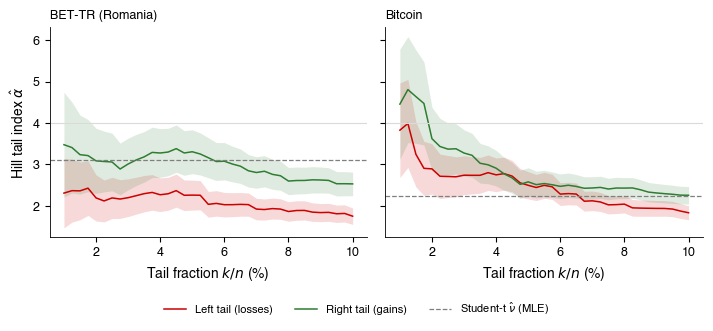

asset,BET-TR (Romania),Bitcoin
n,2992,4384
k,59,87
alpha_left,2.189264,2.890881
ci_left,"(1.6306288103270705, 2.7478988849206885)","(2.283408794914191, 3.498354084353436)"
alpha_right,3.084439,3.620397
ci_right,"(2.2973816746320073, 3.871495770206749)","(2.8596285657231864, 4.381166129741307)"
z_diff,-1.817879,-1.468704
p_diff,0.069083,0.141913
nu_mle,3.097034,2.229264


In [27]:
# Solution
def hill_tails(assets=('bettr', 'btc'), frac=0.02):
    rows = []
    for a in assets:
        r = rets[a]
        k = int(frac * len(r))
        aL, aR = hill_estimator(-r.values, k), hill_estimator(r.values, k)
        z = (r - r.mean()) / r.std()
        nu = stats.t.fit(z)[0]
        zdiff = (aL - aR) / np.sqrt(aL ** 2 / k + aR ** 2 / k)
        rows.append({'asset': LABELS[a], 'n': len(r), 'k': k, 'alpha_left': aL,
                     'ci_left': (aL * (1 - 1.96 / np.sqrt(k)), aL * (1 + 1.96 / np.sqrt(k))),
                     'alpha_right': aR,
                     'ci_right': (aR * (1 - 1.96 / np.sqrt(k)), aR * (1 + 1.96 / np.sqrt(k))),
                     'z_diff': zdiff, 'p_diff': 2 * stats.norm.sf(abs(zdiff)), 'nu_mle': nu})
    return pd.DataFrame(rows).set_index('asset')


def fig_hill_tails(assets=('bettr', 'btc')):
    fig, axes = plt.subplots(1, len(assets), figsize=(7.2, 3.0), sharey=True)
    for ax, a in zip(axes, assets):
        r = rets[a].values
        for side, x, c, lab in [('left', -r, IDAred, 'Left tail (losses)'), ('right', r, Forest, 'Right tail (gains)')]:
            ks = np.array([max(int(f * len(r)), 5) for f in HILL_FRACS_TAILS])
            al = np.array([hill_estimator(x, k) for k in ks])
            ax.plot(100 * HILL_FRACS_TAILS, al, color=c, lw=1.1, label=lab)
            ax.fill_between(100 * HILL_FRACS_TAILS, al * (1 - 1.96 / np.sqrt(ks)), al * (1 + 1.96 / np.sqrt(ks)),
                            color=c, alpha=0.15, lw=0)
        z = (rets[a] - rets[a].mean()) / rets[a].std()
        ax.axhline(stats.t.fit(z)[0], color=Gray, ls='--', lw=0.9, label='Student-t $\\hat\\nu$ (MLE)')
        ax.axhline(4, color=LightGray, lw=0.8)
        ax.set_title(LABELS[a], fontsize=9, loc='left')
        ax.set_xlabel('Tail fraction $k/n$ (%)')
    axes[0].set_ylabel('Hill tail index $\\hat\\alpha$')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch1_sem_hill_tails')


fig_hill_tails()
hill_tails().T

### B12. The leverage effect as a regression (Newey–West errors, |r| controls) [Proposed]

In [ ]:
# Your code here


### B13. Is the Sharpe difference real? (Jobson–Korkie with the Memmel correction, block bootstrap) [Proposed]

In [ ]:
# Your code here


### B14. Which stylised facts does GARCH(1,1)-t reproduce? [Proposed]

In [ ]:
# Your code here


### B15. Long memory or breaks? Local Whittle d for |r_t| [Proposed]

In [ ]:
# Your code here


## Part C — did BET-TR autocorrelation fall after the 2020 FTSE reclassification? [Proposed]

In [ ]:
# Your code here
